In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import gymnasium as gym
from gymnasium import spaces

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from stable_baselines3 import PPO, DDPG, TD3
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.env_checker import check_env

from sb3_contrib import RecurrentPPO, TRPO

import scipy.io

print("INFO: Import Library")

INFO: Import Library


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# Function to load mat file
def load_mat_file(file_path):
    path =Path(file_path)
    try:
        mat = scipy.io.loadmat(path)
        if 'meas' not in mat:
            print(f"ERROR: Key 'meas' is not found in {path.name}")
            return None

        data_struct = mat["meas"][0,0]
        names = data_struct.dtype.names
        raw_data = {}
        for name in names:
            content = data_struct[name].flatten()

            if len(content) > 0 and isinstance(content[0], np.ndarray):
                raw_data[name] = content[0].flatten()
            else:
                raw_data[name] = content

        lengths = [len(v) for v in raw_data.values() if isinstance(v, (np.ndarray, list))]
        max_len = max(lengths) if lengths else 1

        final_data = {}
        for name, values in raw_data.items():
            curr_len = len(values) if isinstance(values, (np.ndarray, list)) else 1

            if curr_len != max_len:
                single_val = values[0] if curr_len > 0 else np.nan
                if hasattr(single_val, 'decode'):
                    single_val = single_val.decode('utf-8')
                final_data[name] = [single_val] * max_len
            else:
                if isinstance(values, np.ndarray) and values.dtype.kind in ['S', 'V']:
                    final_data[name] = [v.decode('utf-8') if hasattr(v, 'decode') else v for v in values]
                else:
                    final_data[name] = values

        df = pd.DataFrame(final_data)
        return df


    except Exception as e:
        print(f"ERROR: Failed to load {path.name}. {e}")

In [3]:
# Load dataset into df_master
base_path = Path('datasets/1-Open Data')

all_dfs = []

for file_path in base_path.rglob('*.mat'):
    try:
        print(f'INFO: System is processing to load {file_path}')
        df_temp = load_mat_file(str(file_path))
        all_dfs.append(df_temp)
        print(f"INFO: Success to load {file_path}")

    except Exception as e:
        print(f"ERROR: Failed to load {file_path}: {e}")

df_master = pd.concat(all_dfs, ignore_index=True)

valid_temps = [-20, -10, 0, 10, 25, 40]
df_master['Ambient_Temp_degC'] = (
    df_master['Ambient_Temp_degC']
    .apply(lambda x: min(valid_temps, key=lambda t: abs(x - t)))
)

df_master.sample(5)

INFO: System is processing to load datasets/1-Open Data/m1000/40C/Drive Cycles/20_REORDERED6_05-17-21_13.21 Tesla_40C_DriveCycles_Ch4.mat
INFO: Success to load datasets/1-Open Data/m1000/40C/Drive Cycles/20_REORDERED6_05-17-21_13.21 Tesla_40C_DriveCycles_Ch4.mat
INFO: System is processing to load datasets/1-Open Data/m1000/40C/Drive Cycles/30_HWGRADE1_05-21-21_01.47 Tesla_40C_DriveCycles_Ch4.mat
INFO: Success to load datasets/1-Open Data/m1000/40C/Drive Cycles/30_HWGRADE1_05-21-21_01.47 Tesla_40C_DriveCycles_Ch4.mat
INFO: System is processing to load datasets/1-Open Data/m1000/40C/Drive Cycles/22_REORDERED7_05-18-21_05.14 Tesla_40C_DriveCycles_Ch4.mat
INFO: Success to load datasets/1-Open Data/m1000/40C/Drive Cycles/22_REORDERED7_05-18-21_05.14 Tesla_40C_DriveCycles_Ch4.mat
INFO: System is processing to load datasets/1-Open Data/m1000/40C/Drive Cycles/17_CC_CV_charge_05-16-21_06.54 Tesla_40C_DriveCycles_Ch4.mat
INFO: Success to load datasets/1-Open Data/m1000/40C/Drive Cycles/17_CC_CV_

,TimeStamp,Time,Voltage,Current,Ah,SOC,Power,Wh,Battery_Temp_degC,Ambient_Temp_degC,Cycle_Label,Test_Cell
16411231,"[b'', b'MCOS', b'datetime', [[3707764736], [2]...",429822.191000,4.175849,0.000000,0.000000,1.000000,0.000000,0.000000,25.425000,25,REORDERED6,m448-N
6688657,"[b'', b'MCOS', b'datetime', [[3707764736], [2]...",352829.061000,3.719804,-0.225633,2.112271,0.508914,-0.839309,8.250213,1.052508,0,C_20_Discharge_Charge,m1000
23798920,"[b'', b'MCOS', b'datetime', [[3707764736], [2]...",572059.544767,3.949136,0.000000,0.000000,1.000000,0.000000,0.000000,23.991736,25,CC_CV_charge,m80
6272921,"[b'', b'MCOS', b'datetime', [[3707764736], [2]...",405585.680270,4.199973,0.082237,0.000678,0.999847,0.345394,-0.407378,11.047222,10,C_20_Discharge_Charge,m1000
13374117,"[b'', b'MCOS', b'datetime', [[3707764736], [2]...",440193.484956,4.190824,0.000000,0.082927,0.980519,0.000000,-0.444422,-7.125250,25,Other,m448-N


In [9]:
duplicate_rows = df_master[df_master.duplicated(
    subset=['Time', 'Ambient_Temp_degC', 'Cycle_Label', 'Test_Cell'],
    keep=False
)]
print(f'INFO: Total column before remove duplicate rows is {len(df_master)}')
print(f'INFO: Total duplicate rows is {len(duplicate_rows)}')
df_master = df_master.drop_duplicates(
    subset=['Time', 'Ambient_Temp_degC', 'Cycle_Label', 'Test_Cell']
)
print('INFO: Remove duplicate is success')
print(f'INFO: Total column after remove duplicate rows is {len(df_master)}')

INFO: Total column before remove duplicate rows is 24414825
INFO: Total duplicate rows is 4738433
INFO: Remove duplicate is success
INFO: Total column after remove duplicate rows is 20190922


In [10]:
# Data Split
from sklearn.model_selection import train_test_split

episode_keys = df_master[['Test_Cell', 'Cycle_Label', 'Ambient_Temp_degC']].drop_duplicates()

train_keys, test_keys = train_test_split(
    episode_keys,
    test_size=0.2,
    random_state=42
)

df_train = df_master.merge(
    train_keys,
    on=['Test_Cell', 'Cycle_Label', 'Ambient_Temp_degC']
)

df_test = df_master.merge(
    test_keys,
    on=['Test_Cell', 'Cycle_Label', 'Ambient_Temp_degC']
)

print(f"Train rows : {len(df_train)}")
print(f"Test rows  : {len(df_test)}")

Train rows : 15045433
Test rows  : 5145489


In [29]:
df_master[df_master['Test_Cell'] == 'm448-N'].Cycle_Label.value_counts()

Cycle_Label
CC_CV_charge             3537873
C_20_Discharge_Charge     753373
HPPC                      667942
Other                     628973
40C_Discharge             444403
REORDERED1                 60225
C_3_Discharge              57207
0.5C_Discharge             23826
HWCUST1                     5497
Name: count, dtype: int64

In [11]:
# Data Preprocessing
from sklearn.preprocessing import MinMaxScaler

features = ['Voltage', 'Current', 'Battery_Temp_degC']

scaler = MinMaxScaler()


df_train[features] = scaler.fit_transform(df_train[features])
df_test[features] = scaler.transform(df_test[features])

In [41]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class BatteryEnv(gym.Env):
    def __init__(self, df):
        super(BatteryEnv, self).__init__()
        self.df = df

        # self.features = ['Voltage', 'Current', 'Battery_Temp_degC']   
        self.features = ['Voltage', 'Current', 'Ah', 'Power', 'Wh']        
        
        self.episode_groups = list(df.groupby(['Test_Cell', 'Cycle_Label', 'Ambient_Temp_degC']).groups.keys())
        
        self.action_space = spaces.Box(low=0.0, high=1.0, shape=(1,), dtype=np.float32)
        
        self.observation_space = spaces.Box(
            low=-np.inf, 
            high=np.inf, 
            shape=(len(self.features),), 
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        idx = np.random.choice(len(self.episode_groups))
        cell_id, cycle_id, ambient_temp = self.episode_groups[idx]
        
        self.episode_data = self.df[
            (self.df['Test_Cell'] == cell_id) & 
            (self.df['Cycle_Label'] == cycle_id) &
            (self.df['Ambient_Temp_degC'] == ambient_temp)
        ].sort_values('Time').reset_index(drop=True)
        
        self.current_step = 0
        return self._get_obs(), {}

    def _get_obs(self):
        row = self.episode_data.iloc[self.current_step]
        return row[self.features].values.astype(np.float32)

    def step(self, action):
        target_soc = self.episode_data.iloc[self.current_step]['SOC']
        error = abs(action[0] - target_soc)
        reward = -error 
        
        if error < 0.01:
            reward += 0.5

        self.current_step += 1
        
        terminated = self.current_step >= len(self.episode_data) - 1
        truncated = False
        
        if not terminated:
            obs = self._get_obs()
        else:
            obs = np.zeros(self.observation_space.shape, dtype=np.float32)
        
        return obs, reward, terminated, truncated, {"target": target_soc}

In [42]:
train_env = BatteryEnv(df_train)
n_actions = train_env.action_space.shape[-1]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))


In [43]:
from stable_baselines3 import DDPG
from stable_baselines3.common.noise import NormalActionNoise
import torch

model = DDPG(
    "MlpPolicy",
    train_env,
    action_noise=action_noise,
    verbose=1,
    learning_rate=0.001,
    buffer_size=100000,
    batch_size=64,
    tau=0.005,
    gamma=0.99,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

model.learn(total_timesteps=100000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [44]:
test_env = BatteryEnv(df_test)

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

all_rmse = []
all_mae = []

results_per_cycle = []
for cell_id, cycle_id, ambient_temp in test_env.episode_groups:

    episode_data = df_test[
        (df_test['Test_Cell'] == cell_id) &
        (df_test['Cycle_Label'] == cycle_id) &
        (df_test['Ambient_Temp_degC'] == ambient_temp)
    ].sort_values('Time').reset_index(drop=True)

    if len(episode_data) < 5:
        continue

    test_env.episode_data = episode_data
    test_env.current_step = 0

    obs = test_env._get_obs()

    done = False

    soc_predictions = []
    soc_actuals = []

    while not done:

        action, _ = model.predict(obs, deterministic=True)

        pred_soc = action[0]

        actual_soc = test_env.episode_data.iloc[
            test_env.current_step
        ]['SOC']

        soc_predictions.append(pred_soc)
        soc_actuals.append(actual_soc)

        obs, reward, terminated, truncated, info = test_env.step(action)

        done = terminated or truncated

    rmse = np.sqrt(
        mean_squared_error(
            soc_actuals,
            soc_predictions
        )
    )

    mae = mean_absolute_error(
        soc_actuals,
        soc_predictions
    )

    all_rmse.append(rmse)
    all_mae.append(mae)

    results_per_cycle.append({
        'cell_id': cell_id,
        'cycle_id': cycle_id,
        'ambient_temp': ambient_temp,
        'rmse': rmse,
        'mae': mae,
        'actual': soc_actuals,
        'predicted': soc_predictions
    })

    print(
        f'Cell={cell_id} | '
        f'Cycle={cycle_id} | '
        f'Temp={ambient_temp} | '
        f'RMSE={rmse:.4f} | MAE={mae:.4f}'
    )

Cell=m1000 | Cycle=40C_Discharge | Temp=0 | RMSE=0.0000 | MAE=0.0000
Cell=m1000 | Cycle=CC_CV_charge | Temp=-20 | RMSE=0.5148 | MAE=0.3938
Cell=m1000 | Cycle=CC_CV_charge | Temp=10 | RMSE=0.7831 | MAE=0.6864
Cell=m1000 | Cycle=CC_CV_charge | Temp=25 | RMSE=0.3246 | MAE=0.1480
Cell=m1000 | Cycle=HPPC | Temp=-20 | RMSE=0.3879 | MAE=0.3061
Cell=m1000 | Cycle=HPPC | Temp=-10 | RMSE=0.5117 | MAE=0.4077
Cell=m1000 | Cycle=HPPC | Temp=10 | RMSE=0.5742 | MAE=0.4861
Cell=m1000 | Cycle=Other | Temp=0 | RMSE=0.3539 | MAE=0.2206
Cell=m1000 | Cycle=Other | Temp=25 | RMSE=0.3068 | MAE=0.1697
Cell=m448-N | Cycle=40C_Discharge | Temp=40 | RMSE=0.5596 | MAE=0.4722
Cell=m448-N | Cycle=CC_CV_charge | Temp=0 | RMSE=0.5214 | MAE=0.3097
Cell=m448-N | Cycle=CC_CV_charge | Temp=40 | RMSE=0.7232 | MAE=0.5310
Cell=m448-N | Cycle=C_3_Discharge | Temp=-10 | RMSE=0.5049 | MAE=0.4372
Cell=m448-N | Cycle=HWCUST1 | Temp=-20 | RMSE=0.4365 | MAE=0.3792
Cell=m448-N | Cycle=Other | Temp=40 | RMSE=0.5802 | MAE=0.4792
Cell

In [45]:
print("\n===== OVERALL TEST PERFORMANCE =====")

print(f"Average RMSE : {np.mean(all_rmse):.6f}")
print(f"Average MAE  : {np.mean(all_mae):.6f}")


===== OVERALL TEST PERFORMANCE =====
Average RMSE : 0.462344
Average MAE  : 0.364278


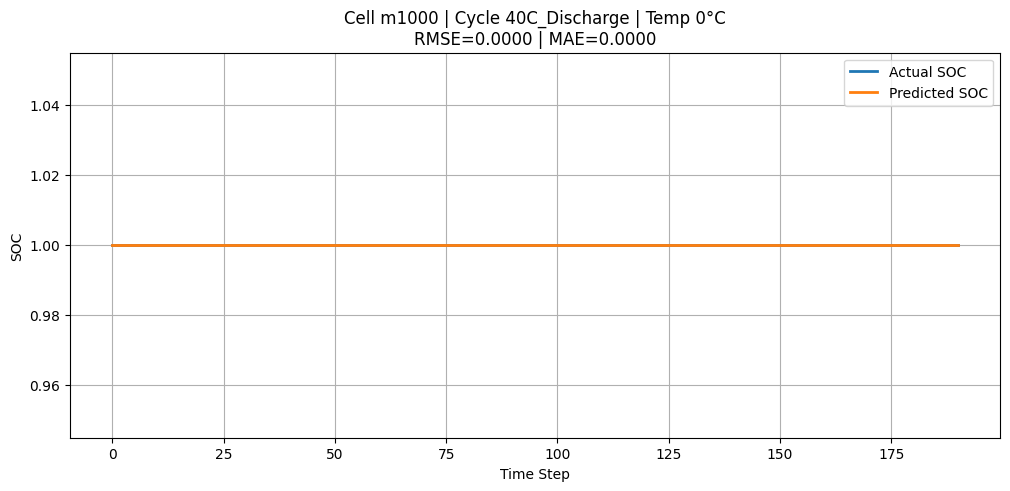

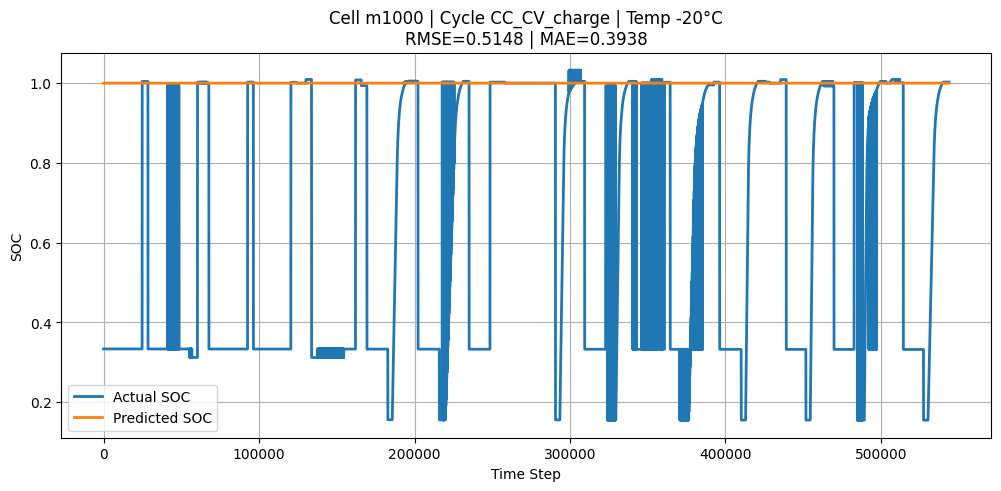

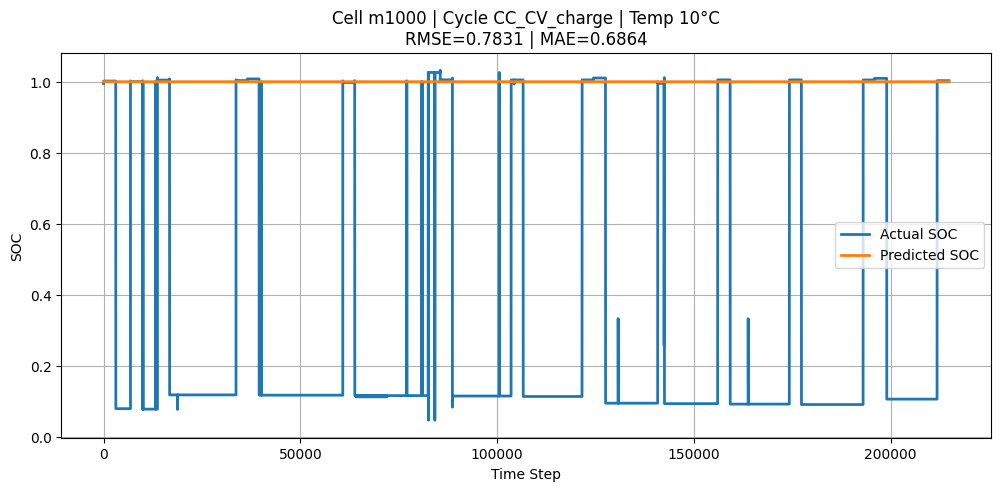

/home/ugm/Repository/undergraduate-thesis-research/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


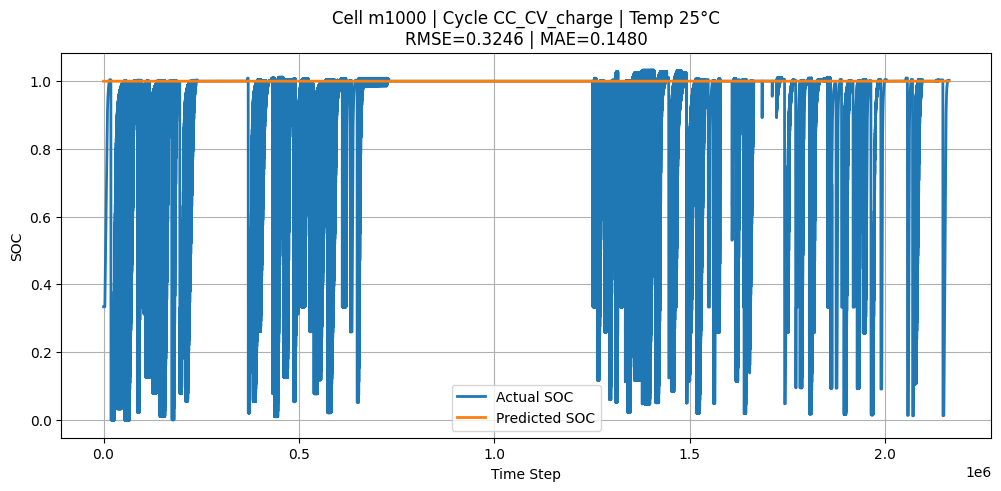

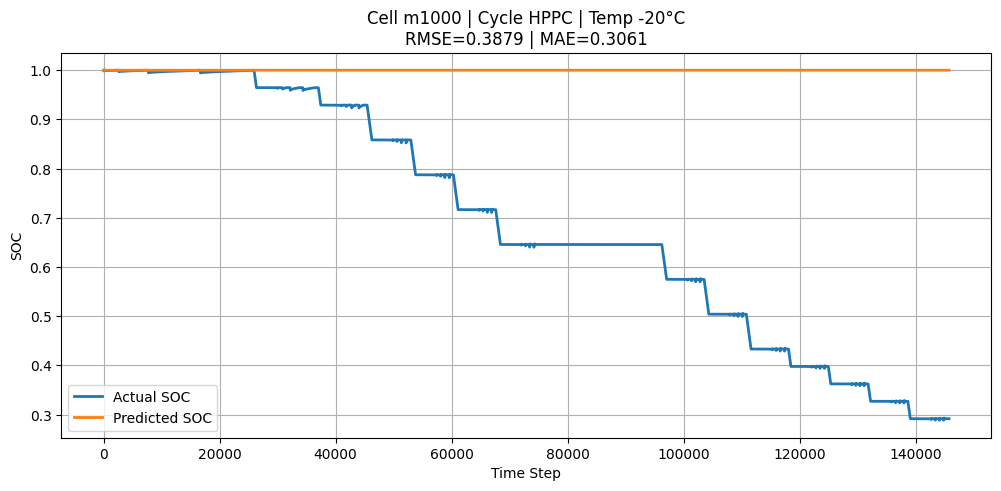

In [46]:
num_plots = min(5, len(results_per_cycle))

for i in range(num_plots):

    result = results_per_cycle[i]

    plt.figure(figsize=(12,5))

    plt.plot(
        result['actual'],
        label='Actual SOC',
        linewidth=2
    )

    plt.plot(
        result['predicted'],
        label='Predicted SOC',
        linewidth=2
    )

    plt.title(
        f"Cell {result['cell_id']} | "
        f"Cycle {result['cycle_id']} | "
        f"Temp {result['ambient_temp']}°C\n"
        f"RMSE={result['rmse']:.4f} | "
        f"MAE={result['mae']:.4f}"
    )

    plt.xlabel('Time Step')
    plt.ylabel('SOC')

    plt.legend()
    plt.grid(True)

    plt.show()

In [24]:
df_master['Ambient_Temp_degC'].unique()

array([ 40,  25,   0,  10, -20, -10])

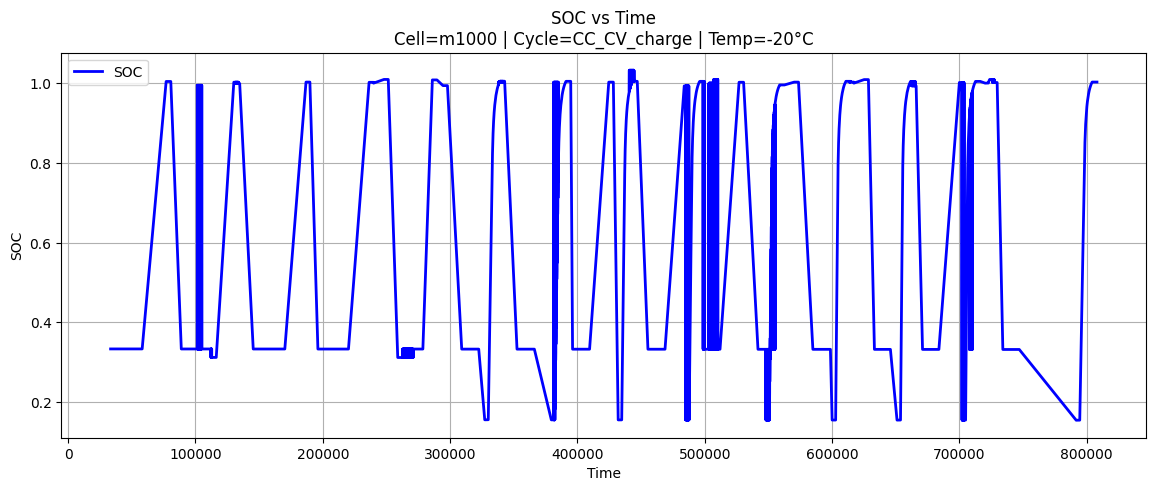

In [30]:
import matplotlib.pyplot as plt

plot_df = df_master[
    (df_master['Test_Cell'] == 'm1000') &
    (df_master['Cycle_Label'] == 'CC_CV_charge') &
    (df_master['Ambient_Temp_degC'] == -20)
][['Time', 'SOC']].sort_values('Time')

plt.figure(figsize=(14, 5))

plt.plot(
    plot_df['Time'],
    plot_df['SOC'],
    linewidth=2,
    color='blue',
    label='SOC'
)

plt.title(
    'SOC vs Time\n'
    'Cell=m1000 | Cycle=CC_CV_charge | Temp=-20°C'
)

plt.xlabel('Time')
plt.ylabel('SOC')

plt.grid(True)
plt.legend()

plt.show()

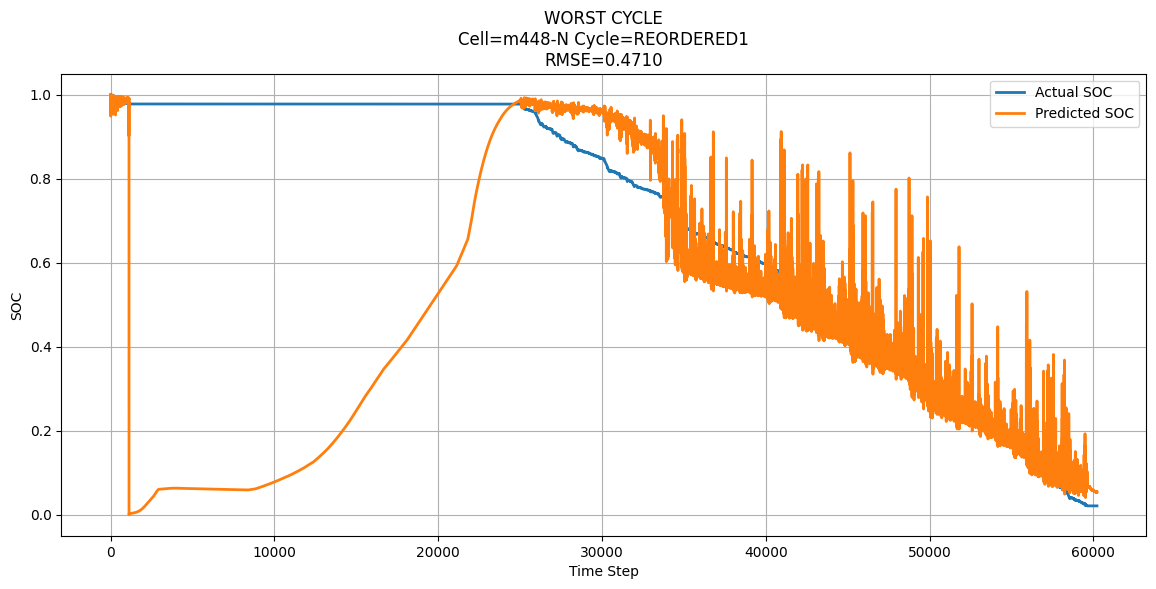

In [68]:
# Sort berdasarkan RMSE terbesar
results_sorted = sorted(
    results_per_cycle,
    key=lambda x: x['rmse'],
    reverse=True
)

worst = results_sorted[0]

plt.figure(figsize=(14,6))

plt.plot(
    worst['actual'],
    label='Actual SOC',
    linewidth=2
)

plt.plot(
    worst['predicted'],
    label='Predicted SOC',
    linewidth=2
)

plt.title(
    f"WORST CYCLE\n"
    f"Cell={worst['cell_id']} "
    f"Cycle={worst['cycle_id']}\n"
    f"RMSE={worst['rmse']:.4f}"
)

plt.xlabel('Time Step')
plt.ylabel('SOC')

plt.legend()
plt.grid(True)

plt.show()

array([[<Axes: title={'center': 'Ambient_Temp_degC'}>]], dtype=object)

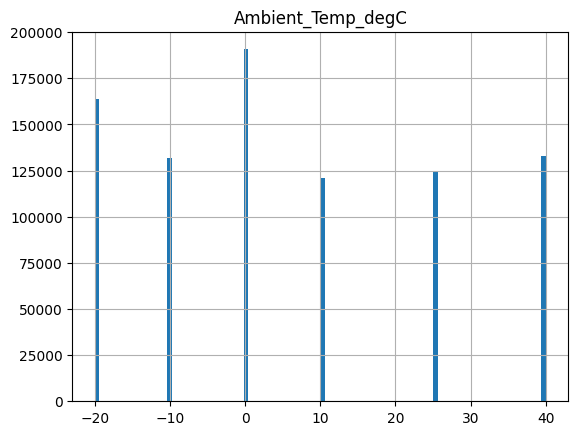

In [75]:
df_test[['Ambient_Temp_degC', 'Test_Cell']].hist(bins=100)